# **LAB DAY 4: GraphRAG**

---
## Pipeline GraphRAG

```
┌─────────────────┐     ┌──────────────────┐     ┌──────────────────┐     ┌─────────────────┐    ┌────────────┐
│  1. Query       │───▶│  2. Seed Node     │───▶│  3. Graph        │───▶│  4.             │───▶│ 5.         │
│  Processing     │     │  Matching        │     │  Traversal (BFS) │     │  Textualization │    │ Generation │
└─────────────────┘     └──────────────────┘     └──────────────────┘     └─────────────────┘    └────────────┘
```

| Bước | Tên | Nhiệm vụ |
|------|-----|----------|
| 1 | **Query Processing** | Trích xuất thực thể từ câu hỏi |
| 2 | **Seed Node Matching** | Tìm node gốc trong Graph DB (exact + semantic) |
| 3 | **Graph Traversal (BFS)** | Khám phá vùng lân cận 2-hop quanh seed node |
| 4 | **Textualization** | Chuyển subgraph → đoạn văn bản để LLM đọc được |
| 5 | **Generation** | LLM tổng hợp câu trả lời cuối cùng |


> **Depth = 2 là tiêu chuẩn khuyên dùng** — Depth 1 quá nông (mất multi-hop), Depth 3+ gây nhiễu Context Window.

---
## **Hybrid Search Architecture**

```
                        Query
                       /     \
               Vector DB    Graph DB
                       \     /
                   LLM Context Window
```
- **Vector DB**: Tìm kiếm ngữ nghĩa → truy xuất chunks văn bản liên quan
- **Graph DB**: Duyệt đồ thị → khai thác quan hệ thực thể phức tạp
- **Kết hợp cả hai** cho context phong phú nhất → ít ảo giác nhất

---
## **A quick introduction to Neo4j**

| Khái niệm | Giải thích | Ví dụ |
|-----------|-----------|-------|
| **Node** | Thực thể (đỉnh của đồ thị) | `(OpenAI)`, `(Sam Altman)` |
| **Relationship** | Quan hệ giữa hai node (cạnh) | `-[:FOUNDED_BY]->` |
| **Property** | Thuộc tính của node/relationship | `{name: 'OpenAI', founded: 2015}` |
| **Cypher** | Ngôn ngữ truy vấn của Neo4j (như SQL) | `MATCH (n:Company) RETURN n` |
| **Label** | Loại/nhóm của node | `:Company`, `:Person`, `:Year` |

### **Basic Cypher Syntax**
```cypher
# Tạo node
CREATE (n:Company {name: 'OpenAI'})

# Tạo quan hệ
MATCH (a:Company {name:'OpenAI'}), (b:Person {name:'Sam Altman'})
CREATE (a)-[:FOUNDED_BY]->(b)

# Truy vấn
MATCH (c:Company)-[:FOUNDED_BY]->(p:Person)
RETURN c.name, p.name
```

---
## **Installation required**
```bash
docker run \
  --name neo4j-lab \
  -p 7474:7474 -p 7687:7687 \
  -e NEO4J_AUTH=neo4j/password123 \
  neo4j:latest
```
Sau đó mở **http://localhost:7474** để xem giao diện đồ thị trực quan.


## **STEP 0: Install the library**

In [54]:
!pip install neo4j openai pandas networkx matplotlib numpy -q

## **STEP 1: Configure the connection**

In [ ]:
import os
import json
import time
import pandas as pd
import numpy as np
from neo4j import GraphDatabase
from openai import OpenAI

# Configs
NEO4J_URI      = "bolt://localhost:7687"
NEO4J_USER     = "neo4j"
NEO4J_PASSWORD = "password123"

OPENAI_API_KEY = "API_KEY_HERE"

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
client_llm = OpenAI()

# Connect to Neo4j
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))

try:
    with driver.session() as session:
        result = session.run("RETURN 'Neo4j connected successfully!' AS message")
        print(result.single()["message"])
except Exception as e:
    print(f"[!] Connection error: {e}")
    print("[!] Make sure Neo4j is running (Docker or Desktop)")


Neo4j connected successfully!


## **STEP 2: Corpus — Wikipedia-style articles about AI companies**

Each item in CORPUS is a **Wikipedia-style paragraph** about one entity (company or person).

**Designed to make Flat RAG fail on Query 2:**
- The *OpenAI* article names co-founders (Ilya Sutskever) but **does not mention** that Ilya was at Google
- The *Ilya Sutskever* article says he worked at Google Brain but **does not mention** that he co-founded OpenAI
- Flat RAG cannot connect 2 separate chunks; GraphRAG follows the  ->  edge


In [73]:
# Each element = 1 Wikipedia-style paragraph about 1 entity
# Key design: chain-connecting facts are NOT in the same paragraph
#   -> Flat RAG cannot join them; GraphRAG follows graph edges

CORPUS = [
    # --- AI Companies ---
    """OpenAI is an American artificial intelligence research organization founded in December 2015.
    It is headquartered in San Francisco, California. The company's co-founders include
    Sam Altman, Greg Brockman, Ilya Sutskever, Wojciech Zaremba, and John Schulman.
    Sam Altman serves as CEO. OpenAI develops and maintains the GPT series of large language models,
    and created ChatGPT, which became the fastest-growing consumer application in history.
    OpenAI operates as a capped-profit company with a nonprofit parent organization.""",

    """Anthropic is an AI safety company founded in 2021 and headquartered in San Francisco.
    It was co-founded by Dario Amodei and Daniela Amodei, along with several colleagues.
    Dario Amodei serves as CEO and Daniela Amodei as President. Anthropic's primary product
    is Claude, a large language model built on Constitutional AI — a safety technique developed
    internally. Google has invested over 300 million dollars in Anthropic. Anthropic focuses
    on AI safety research alongside commercial model development.""",

    """DeepMind is a British AI research laboratory founded in London in 2010 by Demis Hassabis,
    Shane Legg, and Mustafa Suleyman. Google acquired DeepMind in 2014.
    Demis Hassabis continues to serve as CEO. DeepMind is known for AlphaGo, the first AI system
    to defeat a world champion at the board game Go, defeating Lee Sedol in 2016.
    DeepMind also created AlphaFold, which solved the protein structure prediction problem —
    a major breakthrough recognized by Science magazine as the scientific breakthrough of 2021.""",

    """Character.AI is an American AI company that develops large language models for conversational
    applications. It was co-founded in 2021 by Noam Shazeer and Daniel De Freitas.
    Noam Shazeer serves as CEO. The company is headquartered in Menlo Park, California,
    and has raised significant venture capital funding. Character.AI's platform allows users
    to create and interact with AI characters.""",

    """Inflection AI is an artificial intelligence company co-founded in 2022 by Mustafa Suleyman,
    Reid Hoffman, and Karén Simonyan. Mustafa Suleyman serves as CEO.
    The company created Pi, a personal AI assistant. In 2024, Microsoft acquired most of
    Inflection AI's team and assets, with Mustafa Suleyman joining Microsoft to lead
    Microsoft AI as Executive Vice President.""",

    """Safe Superintelligence Inc. (SSI) is an AI safety startup founded in 2024 by Ilya Sutskever,
    Daniel Gross, and Daniel Levy. Ilya Sutskever, who previously led research at a major AI lab,
    serves as a co-founder focused on building safe superintelligence as the company's sole objective.
    SSI is headquartered in Palo Alto, California.""",

    # --- People (facts about career history SEPARATED from company founding facts) ---
    """Ilya Sutskever is a computer scientist specializing in machine learning and deep learning.
    He was born in Russia and completed his PhD at the University of Toronto under the supervision
    of Geoffrey Hinton. During his doctoral studies, Sutskever co-developed AlexNet, which won
    the ImageNet Large Scale Visual Recognition Challenge in 2012. He subsequently joined
    Google Brain as a research scientist, where he conducted deep learning research from 2012 to 2015.
    He left Google Brain in 2015.""",

    """Noam Shazeer is a software engineer and researcher who spent approximately 20 years at Google.
    At Google, he was a principal engineer and contributed to multiple projects including
    the development of large-scale language models. He is a co-author of the seminal paper
    'Attention Is All You Need' (2017), which introduced the Transformer architecture that
    underpins all modern large language models. He departed from Google in 2021.""",

    """Mustafa Suleyman is a British AI entrepreneur and executive. He co-founded DeepMind in 2010
    and served as its Head of Applied AI. Following Google's acquisition of DeepMind in 2014,
    he worked within the Google/Alphabet ecosystem. He left DeepMind in 2019 and subsequently
    joined Google as Vice President of AI Policy and Product before departing in 2022.
    He holds dual citizenship and studied philosophy at Oxford before entering the technology industry.""",

    """Dario Amodei is an American artificial intelligence researcher. He holds a PhD in computational
    neuroscience from Princeton University. He joined OpenAI in 2016 and served as Vice President
    of Research, leading technical research efforts. He departed from OpenAI in 2021, citing
    differences in approach to AI safety and the direction of the organization. He subsequently
    co-founded a new AI company with his sister Daniela and several colleagues from his previous employer.""",

    """Sam Altman is an American entrepreneur and investor. Before his current role, he was president
    of Y Combinator, the startup accelerator, from 2014 to 2019. He became CEO of a leading AI
    research organization in 2019. He was briefly removed from his CEO position in November 2023
    before being reinstated days later following pressure from employees and investors.
    He is also an investor in several technology companies including Helion Energy and Retro Biosciences.""",

    """Geoffrey Hinton is a British-Canadian cognitive psychologist and computer scientist.
    He is a professor emeritus at the University of Toronto and has been called the
    'Godfather of Deep Learning'. He joined Google in 2013, splitting his time between the
    university and Google Brain. In 2023, he resigned from Google to speak freely about
    the risks of AI development. In 2024, he was awarded the Nobel Prize in Physics jointly
    with John Hopfield for foundational work on artificial neural networks.""",

    """Yann LeCun is a French computer scientist working primarily in machine learning and computer vision.
    He received his PhD from Pierre and Marie Curie University. He worked at Bell Labs and AT&T Labs
    from 1988 to 2002, where he developed convolutional neural networks (CNNs).
    He joined the Courant Institute of Mathematical Sciences at NYU as a professor.
    In 2013, he joined Meta (then Facebook) to establish and lead FAIR, the AI Research division.
    He serves as Chief AI Scientist at Meta.""",

    # --- Technologies (separate facts) ---
    """The Transformer is a deep learning architecture introduced in the 2017 paper
    'Attention Is All You Need' by Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit,
    Llion Jones, Aidan Gomez, Łukasz Kaiser, and Illia Polosukhin — all researchers at Google Brain
    at the time of publication. The Transformer replaced recurrent neural networks with
    a self-attention mechanism, enabling better parallelization. It became the foundation
    for GPT, BERT, Claude, Gemini, and virtually every major language model released after 2018.""",

    """Google Brain was an AI research team within Google, established in 2011 by Andrew Ng,
    Jeff Dean, and Greg Corrado. The team pioneered large-scale deep learning using Google's
    distributed computing infrastructure. Notable researchers who worked at Google Brain include
    Geoffrey Hinton, Ilya Sutskever, Noam Shazeer, Jeff Dean, and many others.
    In 2023, Google Brain merged with DeepMind to form Google DeepMind.""",
]

print(f"Corpus: {len(CORPUS)} Wikipedia-style articles")
print(f"Preview: {CORPUS[0][:120]}...")

Corpus: 15 Wikipedia-style articles
Preview: OpenAI is an American artificial intelligence research organization founded in December 2015.
    It is headquartered in...


## **STEP 3: Extract Entity & Relation**

Use LLM to convert text to a triple list in the format `(Subject, RELATION, Object)`

In [74]:
EXTRACTION_PROMPT = """
You are an expert Knowledge Graph Extraction Engine. Your sole purpose is to extract every possible knowledge triple from the input text with maximum precision and recall.

## OUTPUT FORMAT
Return ONLY a valid JSON object with a single key "triples" whose value is an array of triple objects.
No preamble, no explanation, no markdown fences.

Schema:
{
  "triples": [
    {
      "subject": "canonical entity name",
      "relation": "RELATION_TYPE",
      "object": "canonical entity name or value",
      "subject_type": "<EntityType>",
      "object_type": "<EntityType>"
    }
  ]
}

## ENTITY TYPES
Use exactly one of: Company | Person | Product | Location | Year | Technology | Amount | Event | Role | Industry

## RELATION NAMING RULES
- UPPERCASE_WITH_UNDERSCORE only (e.g. FOUNDED_BY, ACQUIRED, PARTNERED_WITH)
- Be specific: prefer INVESTED_IN over RELATED_TO, CEO_OF over WORKS_AT
- Use active voice from subject → object perspective

## EXTRACTION RULES
1. Extract ALL inferrable triples — do not stop at the obvious ones
2. Normalize entities: use full official names ("Alphabet Inc." not "it")
3. Resolve pronouns and coreferences before extracting
4. One relation per triple — never bundle two facts into one
5. Do NOT hallucinate — every triple must be grounded in the source text
6. Include inverse relationships only if explicitly stated
7. Dates → Year type; monetary values → Amount type

## EXAMPLE
Input:
  "Anthropic, founded by Dario Amodei and Daniela Amodei in 2021, raised $7.3B from Google
   and is headquartered in San Francisco. Its flagship model, Claude, is built on Constitutional AI."

Output:
{
  "triples": [
    {"subject": "Anthropic", "relation": "FOUNDED_BY", "object": "Dario Amodei", "subject_type": "Company", "object_type": "Person"},
    {"subject": "Anthropic", "relation": "FOUNDED_BY", "object": "Daniela Amodei", "subject_type": "Company", "object_type": "Person"},
    {"subject": "Anthropic", "relation": "FOUNDED_IN", "object": "2021", "subject_type": "Company", "object_type": "Year"},
    {"subject": "Anthropic", "relation": "RAISED_FROM", "object": "Google", "subject_type": "Company", "object_type": "Company"},
    {"subject": "Anthropic", "relation": "RAISED_AMOUNT", "object": "$7.3B", "subject_type": "Company", "object_type": "Amount"},
    {"subject": "Anthropic", "relation": "HEADQUARTERED_IN", "object": "San Francisco", "subject_type": "Company", "object_type": "Location"},
    {"subject": "Claude", "relation": "CREATED_BY", "object": "Anthropic", "subject_type": "Product", "object_type": "Company"},
    {"subject": "Claude", "relation": "BUILT_ON", "object": "Constitutional AI", "subject_type": "Product", "object_type": "Technology"}
  ]
}

Now extract all triples from the following text:
"""

def extract_triples(sentence: str) -> list:
    """Use LLM to extract triples from a text sentence."""
    response = client_llm.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": EXTRACTION_PROMPT},
            {"role": "user", "content": f"Văn bản: {sentence}"}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    
    raw = response.choices[0].message.content
    parsed = json.loads(raw)

    # Expected: {"triples": [...]}
    if isinstance(parsed, dict) and "triples" in parsed and isinstance(parsed["triples"], list):
        return parsed["triples"]
    # Fallback: any list value in the object
    if isinstance(parsed, dict):
        for v in parsed.values():
            if isinstance(v, list):
                return v
    if isinstance(parsed, list):
        return parsed
    return []


# Test with one sentence first.
test_sentence = CORPUS[0]
test_triples = extract_triples(test_sentence)
print(f"[Example]: {test_sentence}")
print(f"\n--> Triples extracted:")
for t in test_triples:
    print(f"   ({t['subject']}) --[{t['relation']}]--> ({t['object']})")
print(f"\n   subject_type / object_type: {[(t['subject_type'], t['object_type']) for t in test_triples]}")

[Example]: OpenAI is an American artificial intelligence research organization founded in December 2015.
    It is headquartered in San Francisco, California. The company's co-founders include
    Sam Altman, Greg Brockman, Ilya Sutskever, Wojciech Zaremba, and John Schulman.
    Sam Altman serves as CEO. OpenAI develops and maintains the GPT series of large language models,
    and created ChatGPT, which became the fastest-growing consumer application in history.
    OpenAI operates as a capped-profit company with a nonprofit parent organization.

--> Triples extracted:
   (OpenAI) --[FOUNDED_IN]--> (2015)
   (OpenAI) --[FOUNDED_IN]--> (December)
   (OpenAI) --[HEADQUARTERED_IN]--> (San Francisco)
   (OpenAI) --[HEADQUARTERED_IN]--> (California)
   (OpenAI) --[CO_FOUNDERS]--> (Sam Altman)
   (OpenAI) --[CO_FOUNDERS]--> (Greg Brockman)
   (OpenAI) --[CO_FOUNDERS]--> (Ilya Sutskever)
   (OpenAI) --[CO_FOUNDERS]--> (Wojciech Zaremba)
   (OpenAI) --[CO_FOUNDERS]--> (John Schulman)
   (Sam

In [75]:
# Extract the entire corpus.
all_triples = []
print("--> Extracting knowledge from the entire corpus...\n")

for i, sentence in enumerate(CORPUS):
    triples = extract_triples(sentence)
    all_triples.extend(triples)
    print(f"[{i+1:2d}/{len(CORPUS)}] {len(triples)} triples ← {sentence[:60]}...")
    time.sleep(0.3)  # Avoid rate limits

print(f"\n[-->] Total: {len(all_triples)} triples from {len(CORPUS)} sentences")

--> Extracting knowledge from the entire corpus...

[ 1/15] 16 triples ← OpenAI is an American artificial intelligence research organ...
[ 2/15] 12 triples ← Anthropic is an AI safety company founded in 2021 and headqu...
[ 3/15] 16 triples ← DeepMind is a British AI research laboratory founded in Lond...
[ 4/15] 9 triples ← Character.AI is an American AI company that develops large l...
[ 5/15] 13 triples ← Inflection AI is an artificial intelligence company co-found...
[ 6/15] 8 triples ← Safe Superintelligence Inc. (SSI) is an AI safety startup fo...
[ 7/15] 15 triples ← Ilya Sutskever is a computer scientist specializing in machi...
[ 8/15] 13 triples ← Noam Shazeer is a software engineer and researcher who spent...
[ 9/15] 18 triples ← Mustafa Suleyman is a British AI entrepreneur and executive....
[10/15] 12 triples ← Dario Amodei is an American artificial intelligence research...
[11/15] 13 triples ← Sam Altman is an American entrepreneur and investor. Before ...
[12/15] 14 trip

In [76]:
# Deduplication
# Why is it important? Because many sentences in a text may refer to the same relationship.
# Example: "Sam Altman is CEO" appears in many different sentences.

seen = set()
unique_triples = []

for t in all_triples:
    key = (t['subject'].strip().lower(), t['relation'].strip().upper(), t['object'].strip().lower())
    if key not in seen:
        seen.add(key)
        unique_triples.append(t)

print(f"📊 Before dedup: {len(all_triples)} triples")
print(f"✅ After dedup:   {len(unique_triples)} triples (removed {len(all_triples)-len(unique_triples)} duplicates)")

# View summary of unique triples
df_triples = pd.DataFrame(unique_triples)
df_triples.head(10)

📊 Before dedup: 213 triples
✅ After dedup:   209 triples (removed 4 duplicates)


,subject,relation,object,subject_type,object_type
0,OpenAI,FOUNDED_IN,2015,Company,Year
1,OpenAI,FOUNDED_IN,December,Company,Year
2,OpenAI,HEADQUARTERED_IN,San Francisco,Company,Location
3,OpenAI,HEADQUARTERED_IN,California,Company,Location
4,OpenAI,CO_FOUNDERS,Sam Altman,Company,Person
5,OpenAI,CO_FOUNDERS,Greg Brockman,Company,Person
6,OpenAI,CO_FOUNDERS,Ilya Sutskever,Company,Person
7,OpenAI,CO_FOUNDERS,Wojciech Zaremba,Company,Person
8,OpenAI,CO_FOUNDERS,John Schulman,Company,Person
9,Sam Altman,SERVES_AS,CEO,Person,Role


## **STEP 4: Build the Graph in Neo4j**

This is the main part — pushing all triples into Neo4j using Cypher.

In [77]:
def build_neo4j_graph(driver, triples: list):
    """
    Creating a knowledge graph in Neo4j from a list of triples.

    Strategy:

    1. Use MERGE (not CREATE) to avoid duplicate nodes.
    2. Create indexes to speed up queries.
    3. Each node is assigned a label by type (Company, Person, ...).

    """
    with driver.session() as session:
        # 1. Delete old data (if restarting)
        session.run("MATCH (n) DETACH DELETE n")
        print("Deleted old data from Neo4j")
        
        # 2. Create indexes for fast querying
        for label in ["Company", "Person", "Product", "Location", "Year", "Technology", "Amount"]:
            session.run(f"CREATE INDEX IF NOT EXISTS FOR (n:{label}) ON (n.name)")
        print("📑 Created indexes")
        
        # 3. Push each triple
        count = 0
        for t in triples:
            subj_label = t.get("subject_type", "Entity")
            obj_label  = t.get("object_type",  "Entity")
            relation   = t["relation"].replace(" ", "_").upper()
            subj_name  = t["subject"]
            obj_name   = t["object"]
            
            # Cypher: MERGE ensures no duplicate nodes are created.
            cypher = f"""
            MERGE (a:{subj_label} {{name: $subj}})
            MERGE (b:{obj_label}  {{name: $obj}})
            MERGE (a)-[r:{relation}]->(b)
            """
            session.run(cypher, subj=subj_name, obj=obj_name)
            count += 1
        
        print(f"✅ Created {count} relationships in Neo4j")
        
        # 4. Statistics
        stats = session.run("""
            MATCH (n) WITH count(n) AS nodes
            MATCH ()-[r]->() 
            RETURN nodes, count(r) AS rels
        """).single()
        
        print(f"\n📊 Knowledge Graph Statistics:")
        print(f"   • Nodes (entities): {stats['nodes']}")
        print(f"   • Relationships:    {stats['rels']}")


build_neo4j_graph(driver, unique_triples)

Deleted old data from Neo4j
📑 Created indexes
✅ Created 209 relationships in Neo4j

📊 Knowledge Graph Statistics:
   • Nodes (entities): 162
   • Relationships:    209


In [78]:
# See some sample nodes and relationships.
with driver.session() as session:
    result = session.run("""
        MATCH (a)-[r]->(b)
        RETURN a.name AS subject, type(r) AS relation, b.name AS object,
               labels(a)[0] AS subj_type, labels(b)[0] AS obj_type
        LIMIT 15
    """)
    rows = [dict(record) for record in result]

df_graph = pd.DataFrame(rows)
print("Mẫu dữ liệu trong Neo4j:")
df_graph

Mẫu dữ liệu trong Neo4j:


,subject,relation,object,subj_type,obj_type
0,Anthropic,HEADQUARTERED_IN,San Francisco,Company,Location
1,Anthropic,COFOUNDED_BY,Dario Amodei,Company,Person
2,Anthropic,COFOUNDED_BY,Daniela Amodei,Company,Person
3,Dario Amodei,SERVES_AS,CEO,Person,Role
4,Daniela Amodei,SERVES_AS,President,Person,Role
5,Claude,CREATED_BY,Anthropic,Product,Company
6,Claude,BUILT_ON,Constitutional AI,Product,Technology
7,Google,INVESTED_IN,Anthropic,Company,Company
8,Google,INVESTED_AMOUNT,300 million dollars,Company,Amount
9,Anthropic,FOCUSES_ON,AI safety research,Company,Industry


## **STEP 5: Visualize the graph using NetworkX + Matplotlib**

*(Full graph can be viewed directly at http://localhost:7474)*

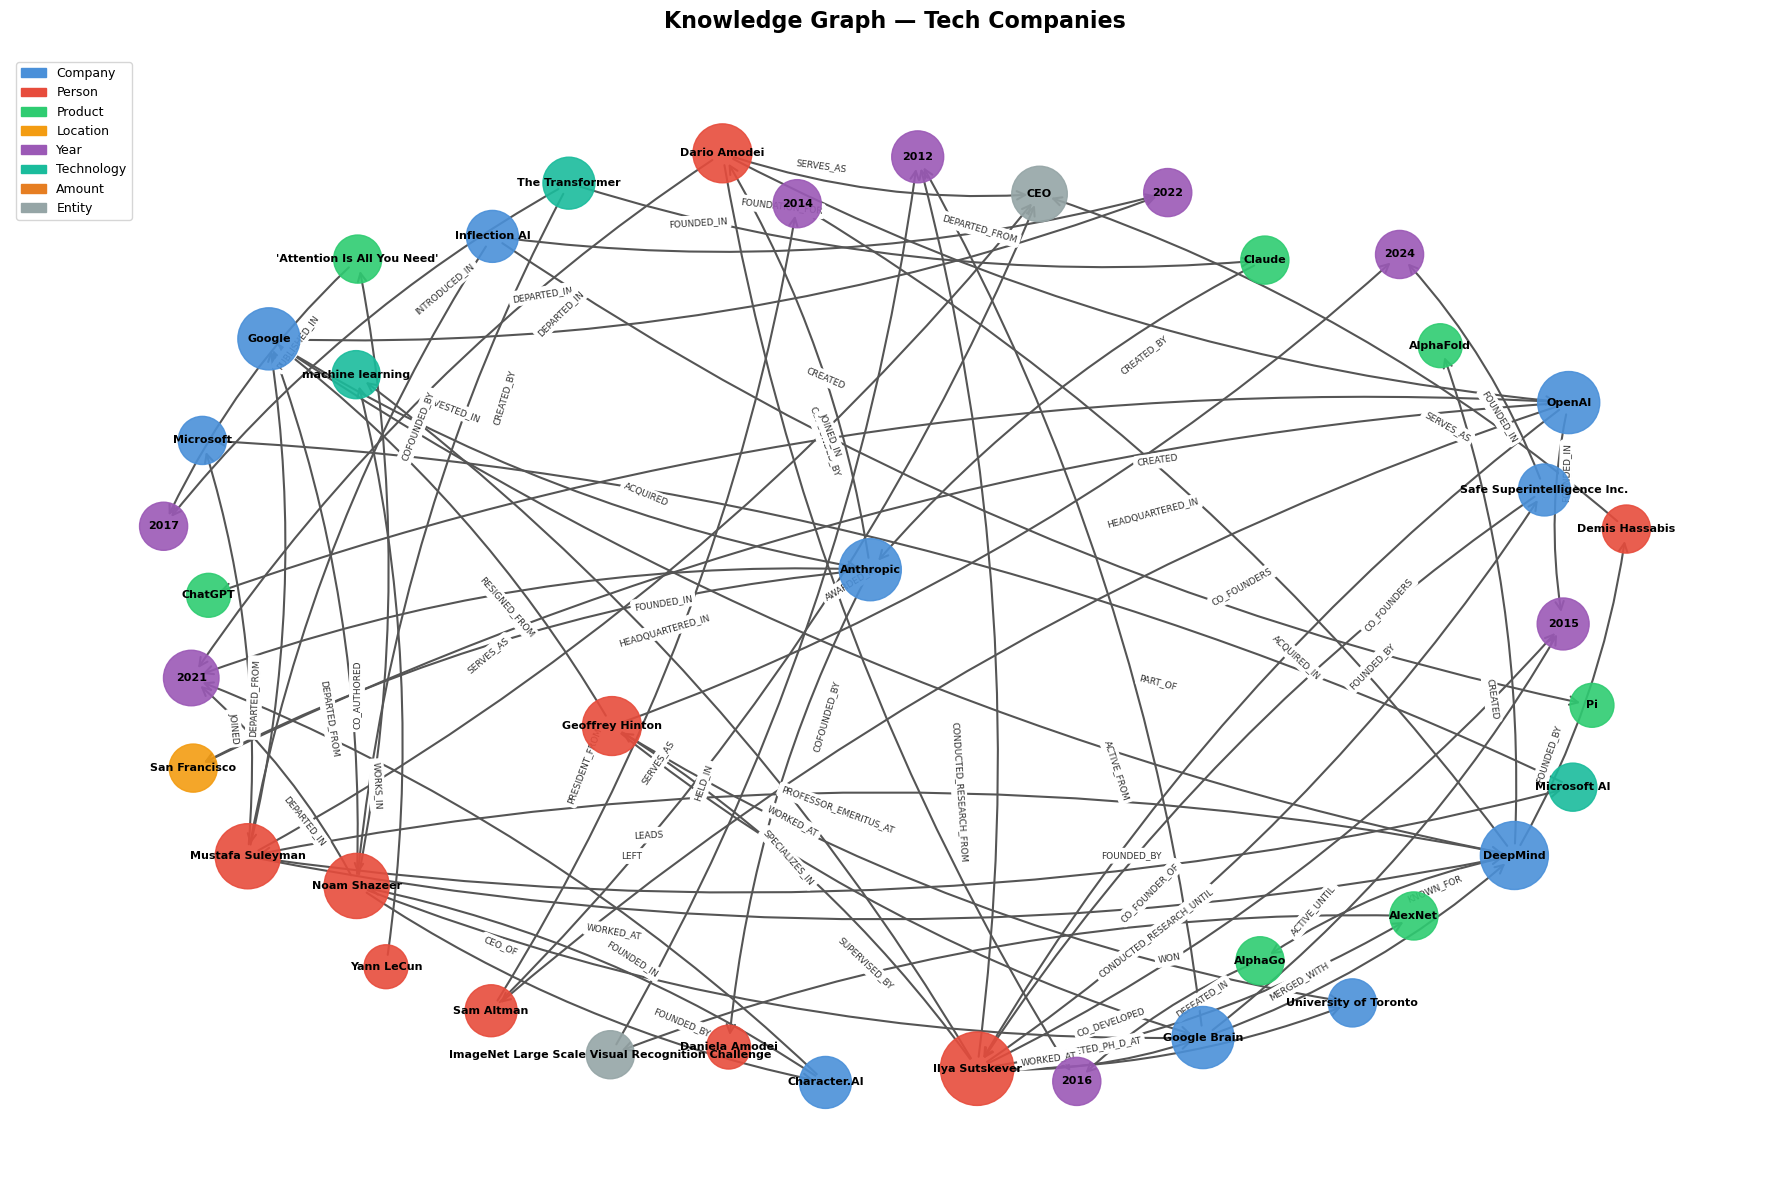

📸 Đã lưu hình tại knowledge_graph.png


In [79]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Color by type
COLOR_MAP = {
    "Company":    "#4A90D9",
    "Person":     "#E74C3C",
    "Product":    "#2ECC71",
    "Location":   "#F39C12",
    "Year":       "#9B59B6",
    "Technology": "#1ABC9C",
    "Amount":     "#E67E22",
    "Entity":     "#95A5A6",
}

def visualize_graph(triples, title="Knowledge Graph — Tech Companies", max_nodes=40):
    G = nx.DiGraph()
    node_labels_map = {}
    
    for t in triples:
        s, r, o = t["subject"], t["relation"], t["object"]
        st = t.get("subject_type", "Entity")
        ot = t.get("object_type",  "Entity")
        G.add_node(s, node_type=st)
        G.add_node(o, node_type=ot)
        G.add_edge(s, o, relation=r)
        node_labels_map[s] = st
        node_labels_map[o] = ot
    
    # Limit the number of nodes to make the graph easier to read.
    if len(G.nodes) > max_nodes:
        # Prioritize nodes with the most connections.
        top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:max_nodes]
        G = G.subgraph([n for n, _ in top_nodes])
    
    plt.figure(figsize=(18, 12))
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    
    pos = nx.spring_layout(G, k=2.5, iterations=50, seed=42)
    
    node_colors = [COLOR_MAP.get(G.nodes[n].get("node_type", "Entity"), "#95A5A6") for n in G.nodes]
    node_sizes  = [800 + G.degree(n) * 200 for n in G.nodes]
    
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')
    nx.draw_networkx_edges(G, pos, edge_color='#555', arrows=True,
                           arrowsize=15, arrowstyle='->', width=1.5,
                           connectionstyle='arc3,rad=0.1')
    
    edge_labels = nx.get_edge_attributes(G, 'relation')
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=6.5,
                                  font_color='#333', label_pos=0.3)
    
    # Legend
    legend_handles = [mpatches.Patch(color=c, label=t) for t, c in COLOR_MAP.items()]
    plt.legend(handles=legend_handles, loc='upper left', fontsize=9)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig("knowledge_graph.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("📸 Đã lưu hình tại knowledge_graph.png")


visualize_graph(unique_triples)

## **STEP 6: GraphRAG Pipeline**

```
Query Processing → Seed Node Matching → Graph Traversal → Textualization → Generation
```

In [80]:
# STEP 1: QUERY PROCESSING
def step1_query_processing(question: str) -> list:
    response = client_llm.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "system",
            "content": """Extract the most important PROPER NAMES from the query (organization, person, product).
                            Only retrieve the names used for database searches - do not retrieve generics.
                            Return JSON: {"entities": ["name1", "name2"]}"""
        }, {
            "role": "user",
            "content": question
        }],
        temperature=0,
        response_format={"type": "json_object"}
    )
    result = json.loads(response.choices[0].message.content)
    return result.get("entities", [])


# STEP 2: SEED NODE MATCHING
def step2_seed_node_matching(driver, entities: list) -> list:
    seed_nodes = []
    with driver.session() as session:
        for entity in entities:
            result = session.run("""
                MATCH (n)
                WHERE toLower(n.name) = toLower($name)
                   OR toLower(n.name) CONTAINS toLower($name)
                   OR toLower($name) CONTAINS toLower(n.name)
                RETURN n.name AS name, labels(n)[0] AS node_type
                LIMIT 3
            """, name=entity)
            seed_nodes.extend([dict(row) for row in result])

    seen = set()
    unique_seeds = []
    for s in seed_nodes:
        if s['name'] not in seen:
            seen.add(s['name'])
            unique_seeds.append(s)
    return unique_seeds


# STEP 3: GRAPH TRAVERSAL (BFS)
def step3_graph_traversal(driver, seed_nodes: list, depth: int = 2) -> list:
    """
    depth=1: Too shallow | depth=2: STANDARD | depth=3+: Too noisy
    
    Fix: r*1..N returns LIST<RELATIONSHIP> — use UNWIND r directly,
    NOT relationships(r) which expects a PATH.
    """
    all_triples = []

    with driver.session() as session:
        for seed in seed_nodes:
            seed_name = seed['name']

            result = session.run(f"""
                MATCH (seed {{name: $seed_name}})-[r*1..{depth}]-(neighbor)
                UNWIND r AS rel
                WITH startNode(rel) AS a, type(rel) AS relation, endNode(rel) AS b
                RETURN DISTINCT a.name AS subject, relation, b.name AS object,
                       labels(a)[0] AS subj_type, labels(b)[0] AS obj_type
                LIMIT 40
            """, seed_name=seed_name)

            for row in result:
                all_triples.append({
                    "subject":   row["subject"],
                    "relation":  row["relation"],
                    "object":    row["object"],
                    "subj_type": row["subj_type"],
                    "obj_type":  row["obj_type"],
                })

    seen = set()
    unique = []
    for t in all_triples:
        key = (t['subject'], t['relation'], t['object'])
        if key not in seen:
            seen.add(key)
            unique.append(t)
    return unique


# STEP 4: TEXTUALIZATION
def step4_textualization(triples: list) -> str:
    if not triples:
        return "No relevant information was found in the knowledge base."
    sentences = [f"{t['subject']} {t['relation'].replace('_', ' ')} {t['object']}" for t in triples]
    return "The following relationships exist in the knowledge base.:\n" + "\n".join(f"• {s}" for s in sentences)


# STEP 5: GENERATION
def step5_generation(question: str, context: str) -> str:
    response = client_llm.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "system",
            "content": """Please answer the user's question using ONLY the context of the relationship provided below.
                          If the context is insufficient, state clearly instead of guessing.
                          Answer in Vietnamese, concisely and accurately."""
        }, {
            "role": "user",
            "content": f"{context}\n\nCÂU HỎI: {question}"
        }],
        temperature=0.1,
        max_tokens=400
    )
    return response.choices[0].message.content


# graphrag_answer() — combines all 5 steps
def graphrag_answer(question: str, driver, depth: int = 2, verbose: bool = True) -> str:
    if verbose:
        print(f"{'='*55}\n[?] Question: {question}\n{'='*55}")

    entities = step1_query_processing(question)
    if verbose:
        print(f"\n[Step 1] Query Processing\n         Entities: {entities}")

    seed_nodes = step2_seed_node_matching(driver, entities)
    if verbose:
        print(f"\n[Step 2] Seed Node Matching")
        for s in seed_nodes:
            print(f"         [✓] ({s['node_type']}) {s['name']}")
        if not seed_nodes:
            print("         [!] No seed nodes found!")

    triples = step3_graph_traversal(driver, seed_nodes, depth=depth)
    if verbose:
        print(f"\n[Step 3] Graph Traversal (BFS, depth={depth})")
        print(f"         {len(triples)} triples retrieved")
        for t in triples[:5]:
            print(f"         • ({t['subject']})─[{t['relation']}]→({t['object']})")
        if len(triples) > 5:
            print(f"         ... and {len(triples)-5} other triples")

    context = step4_textualization(triples)
    if verbose:
        print(f"\n[Step 4] Textualization — {len(context)} characters")

    answer = step5_generation(question, context)
    if verbose:
        print(f"\n[Step 5] Generation\n\n--> Answer: {answer}")

    return answer

## **STEP 7: Flat RAG (Baseline for Comparison)**

Flat RAG uses only similarity searches — no schema structure.

In [90]:
import numpy as np

# 7.1: Create embeddings for the entire corpus
def get_embeddings(texts: list) -> np.ndarray:
    """Create embedding vectors for a list of texts."""
    response = client_llm.embeddings.create(
        model="text-embedding-3-small",
        input=texts
    )
    return np.array([e.embedding for e in response.data])


print("Creating embeddings for the corpus...")
corpus_embeddings = get_embeddings(CORPUS)
print(f"Created {len(corpus_embeddings)} embeddings, each vector: {corpus_embeddings.shape[1]} dimensions")


# 7.2: Flat RAG answer
def flatrag_answer(question: str, top_k=1, verbose=True) -> str:
    """Flat RAG: find top-k similar sentences → send to LLM."""
    
    # Embedding question
    q_embedding = get_embeddings([question])[0]
    
    # Cosine similarity
    corpus_norms = np.linalg.norm(corpus_embeddings, axis=1, keepdims=True)
    q_norm = np.linalg.norm(q_embedding)
    similarities = (corpus_embeddings @ q_embedding) / (corpus_norms.flatten() * q_norm + 1e-8)
    
    # Get top-k
    top_indices = np.argsort(similarities)[::-1][:top_k]
    retrieved = [CORPUS[i] for i in top_indices]
    
    if verbose:
        print(f"Top-{top_k} chunks retrieved (similarity: {similarities[top_indices]})")
    
    context = "\n".join([f"[Chunk {i+1}]: {s}" for i, s in enumerate(retrieved)])
    
    response = client_llm.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "system",
            "content": (
                "You are a retrieval-augmented QA system. "
                "Answer the question using ONLY the exact information explicitly stated in the provided context chunks. "
                "Do NOT use any knowledge from your training data or prior knowledge. "
                "Do NOT infer, guess, or supplement with external information. "
                "If the answer cannot be found explicitly in the provided chunks, respond with exactly: "
                "'Not found in the provided context.' "
                "Answer in English."
            )
        }, {
            "role": "user",
            "content": f"Context:\n{context}\n\nQuestion: {question}"
        }],
        temperature=0,
        max_tokens=400
    )
    
    return response.choices[0].message.content


Creating embeddings for the corpus...
Created 15 embeddings, each vector: 1536 dimensions


In [91]:
# Test
test_q = "Who founded OpenAI and in what year?"
print(f"[?] Question: {test_q}\n")
answer_flat = flatrag_answer(test_q)
print(f"\n--> Flat RAG Answer:\n{answer_flat}")

[?] Question: Who founded OpenAI and in what year?

Top-1 chunks retrieved (similarity: [0.76753934])

--> Flat RAG Answer:
OpenAI was founded by Sam Altman, Greg Brockman, Ilya Sutskever, Wojciech Zaremba, and John Schulman in December 2015.


In [92]:
# So sánh Flat RAG vs GraphRAG 
# Query 1: cả hai đều OK (câu đơn giản, 1 entity)
# Query 2: Flat RAG FAIL, GraphRAG OK (multi-hop, cần nối 2 chunk riêng biệt)

q1 = "What is OpenAI?"
q2 = "Which AI companies were co-founded by former Google employees?"

for q, label in [(q1, "Query 1 — cả hai OK"), (q2, "Query 2 — Flat RAG FAIL")]:
    print(f"\n{'='*60}")
    print(f"[{label}]")
    print(f"Q: {q}")
    print(f"{'='*60}")
    print(f"\n[Flat RAG]")
    print(flatrag_answer(q, top_k=1, verbose=False))
    print(f"\n[GraphRAG]")
    print(graphrag_answer(q, driver, verbose=False))


[Query 1 — cả hai OK]
Q: What is OpenAI?

[Flat RAG]
OpenAI is an American artificial intelligence research organization founded in December 2015. It is headquartered in San Francisco, California. The company develops and maintains the GPT series of large language models and created ChatGPT, which became the fastest-growing consumer application in history. OpenAI operates as a capped-profit company with a nonprofit parent organization.

[GraphRAG]
OpenAI là một tổ chức nghiên cứu trí tuệ nhân tạo được thành lập vào năm 2015, có trụ sở tại San Francisco, California.

[Query 2 — Flat RAG FAIL]
Q: Which AI companies were co-founded by former Google employees?

[Flat RAG]
Not found in the provided context.

[GraphRAG]
Các công ty AI được đồng sáng lập bởi các cựu nhân viên Google bao gồm:

1. Anthropic (do Dario Amodei và Daniela Amodei đồng sáng lập)
2. Character.AI (do Noam Shazeer đồng sáng lập)
3. Inflection AI (do Mustafa Suleyman đồng sáng lập)
4. Safe Superintelligence Inc. (do Ily

## **STEP 8: Hybrid Search — Kết hợp Vector DB + Graph DB**

GraphRAG **không nên thay thế** Vector Search mà nên **bổ trợ** lẫn nhau.
Hybrid Search = Semantic Search (Vector) + Graph Traversal (BFS) → context phong phú nhất.

In [93]:
# HYBRID SEARCH ARCHITECTURE
#
#              Query
#             /     \
#       Vector DB   Graph DB    ← Song song cả hai
#             \     /
#         LLM Context Window
#
# - Vector DB: Semantic search → tìm CHUNKS văn bản liên quan
# - Graph DB:  BFS traversal  → tìm QUAN HỆ thực thể phức tạp
# - Kết hợp cả hai → context đầy đủ nhất, ảo giác thấp nhất
# ══════════════════════════════════════════════════════════════

def hybrid_answer(question: str, driver, top_k: int = 3,
                  depth: int = 2, verbose: bool = True) -> str:
    """
    Hybrid RAG = Vector Search (Flat RAG) + GraphRAG pipeline

    Mechanism:
    1. Use Semantic Search to find seed nodes (instead of exact matches)
    → More robust with different spellings
    2. Then use Graph Traversal to extract relationships
    3. Combine both vector context + graph context → send to LLM
    """
    if verbose:
        print(f"{'='*55}")
        print(f"HYBRID SEARCH")
        print(f"[?]Question: {question}")
        print(f"{'='*55}")
    
    # NHÁNH A: Vector DB (Semantic Search)
    q_embedding = get_embeddings([question])[0]
    corpus_norms = np.linalg.norm(corpus_embeddings, axis=1, keepdims=True)
    q_norm = np.linalg.norm(q_embedding)
    similarities = (corpus_embeddings @ q_embedding) / (corpus_norms.flatten() * q_norm + 1e-8)
    top_indices = np.argsort(similarities)[::-1][:top_k]
    vector_chunks = [CORPUS[i] for i in top_indices]
    
    if verbose:
        print(f"\n[Vector DB] Top-{top_k} chunks found:")
        for chunk in vector_chunks:
            print(f"   • {chunk[:80]}...")
    
    # NHÁNH B: Graph DB (BFS Traversal)
    # Use Semantic Search to find better seed nodes.
    entities = step1_query_processing(question)
    seed_nodes = step2_seed_node_matching(driver, entities)
    graph_triples = step3_graph_traversal(driver, seed_nodes, depth=depth)
    graph_context = step4_textualization(graph_triples)
    
    if verbose:
        print(f"\n[Graph DB] {len(graph_triples)} triples from BFS (depth={depth})")
        print(f"           Seed nodes: {[s['name'] for s in seed_nodes]}")
    
    # COMBINE: Vector chunks + Graph context
    combined_context = f"""=== FROM VECTOR DATABASE (semantics) ===
{chr(10).join(['• ' + c for c in vector_chunks])}

=== FROM GRAPH DATABASE (relationships) ===
{graph_context}"""
    
    # ── GENERATION ──
    response = client_llm.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "system",
            "content": """Please answer the question using ONLY the context provided (from both the Vector DB and the Graph DB).
                        Prioritize information from the Graph DB for relationship questions.
                        If the information is conflicting, the Graph DB is more reliable.
                        Answer in concise Vietnamese."""
        }, {
            "role": "user",
            "content": f"{combined_context}\n\nQUESTION: {question}"
        }],
        temperature=0.2,
        max_tokens=400
    )
    
    answer = response.choices[0].message.content
    if verbose:
        print(f"\n[Hybrid] Answer: {answer}")
    return answer

In [94]:
# Demo Hybrid Search
demo_multihop = "Which organization did the founder of OpenAI previously serve as CEO of?"
_ = hybrid_answer(demo_multihop, driver)

HYBRID SEARCH
[?]Question: Which organization did the founder of OpenAI previously serve as CEO of?

[Vector DB] Top-3 chunks found:
   • OpenAI is an American artificial intelligence research organization founded in D...
   • Dario Amodei is an American artificial intelligence researcher. He holds a PhD i...
   • Sam Altman is an American entrepreneur and investor. Before his current role, he...

[Graph DB] 40 triples from BFS (depth=2)
           Seed nodes: ['OpenAI']

[Hybrid] Answer: Người sáng lập OpenAI, Sam Altman, trước đây đã giữ chức vụ CEO của Y Combinator.


# **STEP 9: Benchmark**

In [95]:
MULTIHOP_QUESTIONS = [
    # Requires joining company article (founders) + person article (worked at Google)
    "Which AI companies were co-founded by former Google employees?",
    # Chain: OpenAI ← CO_FOUNDED_BY ← Ilya ← WORKED_AT ← Google Brain
    "Who founded OpenAI, and where did those founders work before?",
    # Chain: Character.AI ← CO_FOUNDED_BY ← Noam ← CO_AUTHORED ← 'Attention Is All You Need' ← at Google
    "The founder of Character.AI co-authored which influential paper, and while at which company?",
    # Chain: Inflection AI ← CO_FOUNDED_BY ← Mustafa ← CO_FOUNDED ← DeepMind ← ACQUIRED_BY ← Google
    "Which Microsoft executive previously co-founded an AI lab that Google acquired?",
    # Chain: SSI ← CO_FOUNDED_BY ← Ilya ← PHD_SUPERVISED_BY ← Geoffrey Hinton ← AWARDED ← Nobel Prize
    "The co-founder of Safe Superintelligence Inc. was mentored by which Nobel Prize winner?",
]

SIMPLE_QUESTIONS = [
    # AI Companies
    "What is OpenAI?",
    "Who is the CEO of Anthropic?",
    "When was DeepMind founded and in which city?",
    "Who co-founded Character.AI?",
    "What is Safe Superintelligence Inc. (SSI)?",
    # People
    "Who is Yann LeCun and where does he work now?",
    "What Nobel Prize did Geoffrey Hinton receive?",
    "Where did Sam Altman work before becoming CEO of OpenAI?",
    "What is Dario Amodei known for at OpenAI?",
    "Where did Ilya Sutskever complete his PhD and under whose supervision?",
    # Technologies
    "What is the Transformer architecture?",
    "What did AlphaFold solve?",
    "What is Constitutional AI?",
    "What is Google Brain and who founded it?",
    "What did AlphaGo achieve in 2016?",
]

ALL_QUESTIONS = MULTIHOP_QUESTIONS + SIMPLE_QUESTIONS
assert len(ALL_QUESTIONS) == 20, f"Expected 20, got {len(ALL_QUESTIONS)}"
print(f"Benchmark: {len(MULTIHOP_QUESTIONS)} multi-hop + {len(SIMPLE_QUESTIONS)} simple = {len(ALL_QUESTIONS)} total")
print(f"\nMulti-hop (GraphRAG advantage):")
for i, q in enumerate(MULTIHOP_QUESTIONS, 1):
    print(f"  {i}. {q}")
print(f"\nSimple (both systems should handle):")
for i, q in enumerate(SIMPLE_QUESTIONS, 1):
    print(f"  {i}. {q}")


Benchmark: 5 multi-hop + 15 simple = 20 total

Multi-hop (GraphRAG advantage):
  1. Which AI companies were co-founded by former Google employees?
  2. Who founded OpenAI, and where did those founders work before?
  3. The founder of Character.AI co-authored which influential paper, and while at which company?
  4. Which Microsoft executive previously co-founded an AI lab that Google acquired?
  5. The co-founder of Safe Superintelligence Inc. was mentored by which Nobel Prize winner?

Simple (both systems should handle):
  1. What is OpenAI?
  2. Who is the CEO of Anthropic?
  3. When was DeepMind founded and in which city?
  4. Who co-founded Character.AI?
  5. What is Safe Superintelligence Inc. (SSI)?
  6. Who is Yann LeCun and where does he work now?
  7. What Nobel Prize did Geoffrey Hinton receive?
  8. Where did Sam Altman work before becoming CEO of OpenAI?
  9. What is Dario Amodei known for at OpenAI?
  10. Where did Ilya Sutskever complete his PhD and under whose supervisio

In [96]:
# Run benchmark
results = []

print("Đang chạy benchmark 20 câu hỏi (3 hệ thống)...\n" + "="*65)

for i, q in enumerate(ALL_QUESTIONS):
    q_type = "🔴 Multi-hop" if i < len(MULTIHOP_QUESTIONS) else "🟢 Đơn giản"
    print(f"\n[{i+1:2d}/20] {q_type}")
    print(f"❓  {q}")
    
    # System 1: Flat RAG
    flat_ans   = flatrag_answer(q, top_k=1, verbose=False)
    
    # System 2: GraphRAG (5-step pipeline)
    graph_ans  = graphrag_answer(q, driver, verbose=False)
    
    # System 3: Hybrid (Vector + Graph)
    hybrid_ans = hybrid_answer(q, driver, verbose=False)
    
    results.append({
        "ID":       i + 1,
        "Loại":    "Multi-hop" if i < len(MULTIHOP_QUESTIONS) else "Đơn giản",
        "Câu hỏi": q,
        "Flat RAG":  flat_ans,
        "GraphRAG":  graph_ans,
        "Hybrid":    hybrid_ans,
    })
    
    print(f"   📄 Flat:   {flat_ans[:90]}...")
    print(f"   🕸️  Graph:  {graph_ans[:90]}...")
    print(f"   🔀 Hybrid: {hybrid_ans[:90]}...")
    time.sleep(0.5)

print("\n" + "="*65)
print("✅ Benchmark hoàn tất!")

Đang chạy benchmark 20 câu hỏi (3 hệ thống)...

[ 1/20] 🔴 Multi-hop
❓  Which AI companies were co-founded by former Google employees?
   📄 Flat:   Not found in the provided context....
   🕸️  Graph:  Các công ty AI được đồng sáng lập bởi các cựu nhân viên Google bao gồm:

1. Anthropic (do ...
   🔀 Hybrid: Các công ty AI được đồng sáng lập bởi các cựu nhân viên Google bao gồm:

1. Anthropic (đồn...

[ 2/20] 🔴 Multi-hop
❓  Who founded OpenAI, and where did those founders work before?
   📄 Flat:   Not found in the provided context....
   🕸️  Graph:  OpenAI được thành lập bởi Sam Altman, Ilya Sutskever, Greg Brockman, Wojciech Zaremba và J...
   🔀 Hybrid: OpenAI được thành lập bởi Sam Altman, Greg Brockman, Ilya Sutskever, Wojciech Zaremba và J...

[ 3/20] 🔴 Multi-hop
❓  The founder of Character.AI co-authored which influential paper, and while at which company?
   📄 Flat:   Not found in the provided context....
   🕸️  Graph:  Người sáng lập Character.AI, Noam Shazeer, đã đồng tác giả bài 

In [97]:
# Bảng so sánh kết quả benchmark
df_results = pd.DataFrame(results)

# Truncate for readability
display_df = df_results[["ID", "Loại", "Câu hỏi", "Flat RAG", "GraphRAG", "Hybrid"]].copy()
display_df["Flat RAG"] = display_df["Flat RAG"].str[:120] + "..."
display_df["GraphRAG"] = display_df["GraphRAG"].str[:120] + "..."
display_df["Hybrid"]   = display_df["Hybrid"].str[:120]   + "..."

# Highlight multi-hop rows (yellow) — these are where Flat RAG tends to hallucinate
def highlight_multihop(row):
    if row["Loại"] == "Multi-hop":
        return ["background-color: #fff3cd; font-weight: bold"] * len(row)
    return [""] * len(row)

print("BẢNG SO SÁNH: FLAT RAG vs GRAPHRAG vs HYBRID (20 câu hỏi)")
print("Nền vàng = Multi-hop — loại câu hỏi Flat RAG dễ ảo giác, GraphRAG xử lý tốt hơn")
display_df.style.apply(highlight_multihop, axis=1)


BẢNG SO SÁNH: FLAT RAG vs GRAPHRAG vs HYBRID (20 câu hỏi)
Nền vàng = Multi-hop — loại câu hỏi Flat RAG dễ ảo giác, GraphRAG xử lý tốt hơn


,ID,Loại,Câu hỏi,Flat RAG,GraphRAG,Hybrid
0,1,Multi-hop,Which AI companies were co-founded by former Google employees?,Not found in the provided context....,Các công ty AI được đồng sáng lập bởi các cựu nhân viên Google bao gồm: 1. Anthropic (do Dario Amodei và Daniela Amodei...,Các công ty AI được đồng sáng lập bởi các cựu nhân viên Google bao gồm: 1. Anthropic (đồng sáng lập bởi Dario Amodei và...
1,2,Multi-hop,"Who founded OpenAI, and where did those founders work before?",Not found in the provided context....,"OpenAI được thành lập bởi Sam Altman, Ilya Sutskever, Greg Brockman, Wojciech Zaremba và John Schulman. Trước khi thành ...","OpenAI được thành lập bởi Sam Altman, Greg Brockman, Ilya Sutskever, Wojciech Zaremba và John Schulman. Trước khi thành ..."
2,3,Multi-hop,"The founder of Character.AI co-authored which influential paper, and while at which company?",Not found in the provided context....,"Người sáng lập Character.AI, Noam Shazeer, đã đồng tác giả bài báo có ảnh hưởng 'Attention Is All You Need' trong thời g...","Người sáng lập Character.AI, Noam Shazeer, đã đồng tác giả bài báo có ảnh hưởng ""Attention Is All You Need"" trong thời g..."
3,4,Multi-hop,Which Microsoft executive previously co-founded an AI lab that Google acquired?,Not found in the provided context....,Mustafa Suleyman là giám đốc điều hành của Microsoft đã đồng sáng lập một phòng thí nghiệm AI mà Google đã mua lại (Deep...,"Mustafa Suleyman là giám đốc điều hành của Microsoft, người đã đồng sáng lập DeepMind, một phòng thí nghiệm AI mà Google..."
4,5,Multi-hop,The co-founder of Safe Superintelligence Inc. was mentored by which Nobel Prize winner?,Not found in the provided context....,"Người đồng sáng lập của Safe Superintelligence Inc. là Ilya Sutskever, và ông được giám sát bởi Geoffrey Hinton, người đ...","Người đồng sáng lập của Safe Superintelligence Inc. là Ilya Sutskever, người đã được Geoffrey Hinton, người đoạt giải No..."
5,6,Đơn giản,What is OpenAI?,OpenAI is an American artificial intelligence research organization founded in December 2015. It is headquartered in San...,"OpenAI là một tổ chức nghiên cứu trí tuệ nhân tạo được thành lập vào năm 2015, có trụ sở tại San Francisco, California....","OpenAI là một tổ chức nghiên cứu trí tuệ nhân tạo của Mỹ, được thành lập vào tháng 12 năm 2015 và có trụ sở tại San Fran..."
6,7,Đơn giản,Who is the CEO of Anthropic?,Dario Amodei is the CEO of Anthropic....,Dario Amodei là CEO của Anthropic....,Dario Amodei là CEO của Anthropic....
7,8,Đơn giản,When was DeepMind founded and in which city?,DeepMind was founded in 2010 in London....,DeepMind được thành lập vào năm 2010 tại London....,DeepMind được thành lập vào năm 2010 tại London....
8,9,Đơn giản,Who co-founded Character.AI?,Noam Shazeer and Daniel De Freitas....,Noam Shazeer và Daniel De Freitas là những người đồng sáng lập Character.AI....,Character.AI được đồng sáng lập bởi Noam Shazeer và Daniel De Freitas....
9,10,Đơn giản,What is Safe Superintelligence Inc. (SSI)?,"Safe Superintelligence Inc. (SSI) is an AI safety startup founded in 2024 by Ilya Sutskever, Daniel Gross, and Daniel Le...",Safe Superintelligence Inc. là một công ty được thành lập với mục tiêu duy nhất là xây dựng trí tuệ siêu an toàn. Công t...,"Safe Superintelligence Inc. (SSI) là một công ty khởi nghiệp về an toàn trí tuệ nhân tạo, được thành lập vào năm 2024 bở..."


In [ ]:
# Lưu kết quả benchmark ra CSV
df_results.to_csv("benchmark_results.csv", index=False, encoding="utf-8-sig")
print("Saved benchmark results to benchmark_results.csv")
print(f"Total: {len(df_results)} questions | {len(df_results[df_results['Loại']=='Multi-hop'])} multi-hop + {len(df_results[df_results['Loại']=='Đơn giản'])} simple")

## **STEP 10: Cost Analysis (Token Usage & Time)**

In [98]:
import time

# Đo thời gian thực tế
sample_question = "Người sáng lập OpenAI trước đó làm CEO ở đâu, và Microsoft đã đầu tư vào OpenAI không?"

# Đo Flat RAG
t0 = time.time()
flatrag_answer(sample_question, verbose=False)
flat_time = time.time() - t0

# Đo GraphRAG (5-step)
t0 = time.time()
graphrag_answer(sample_question, driver, verbose=False)
graph_time = time.time() - t0

# Đo Hybrid
t0 = time.time()
hybrid_answer(sample_question, driver, verbose=False)
hybrid_time = time.time() - t0

# Ước tính token usage
analysis = {
    "Giai đoạn": [
        "Indexing (Extraction)",
        "Indexing (Embedding)",
        "Query — Flat RAG",
        "Query — GraphRAG (5-step)",
        "Query — Hybrid Search"
    ],
    "Mô hình": [
        "gpt-4o-mini",
        "text-embedding-3-small",
        "gpt-4o-mini",
        "gpt-4o-mini",
        "gpt-4o-mini + embedding"
    ],
    "Token ước tính": [
        f"~{len(CORPUS) * 150:,} tokens (extraction × {len(CORPUS)} câu)",
        f"~{sum(len(s.split()) for s in CORPUS):,} tokens (corpus)",
        "~500-800 tokens/query",
        "~800-1,500 tokens/query (graph context)",
        "~1,200-2,000 tokens/query (vector + graph)"
    ],
    "Chi phí USD (~)": [
        f"${len(CORPUS) * 150 * 0.00000015:.4f}",
        f"${sum(len(s.split()) for s in CORPUS) * 0.00000002:.6f}",
        "$0.0001/query",
        "$0.0002/query",
        "$0.0003/query"
    ],
    "Thời gian (sample)": [
        f"~{len(CORPUS) * 0.5:.0f}s (serial)",
        "~2-3s",
        f"{flat_time:.2f}s",
        f"{graph_time:.2f}s",
        f"{hybrid_time:.2f}s"
    ]
}

df_cost = pd.DataFrame(analysis)
print("PHÂN TÍCH CHI PHÍ (3 hệ thống)\n")
print(df_cost.to_string(index=False))
print(f"""
📝 NHẬN XÉT:
• Flat RAG nhanh nhất ({flat_time:.2f}s) nhưng thiếu cấu trúc quan hệ, dễ ảo giác với câu multi-hop
• GraphRAG ({graph_time:.2f}s): chính xác hơn nhờ 5-step pipeline, đặc biệt với câu hỏi quan hệ
• Hybrid ({hybrid_time:.2f}s): tốt nhất — kết hợp ngữ nghĩa + cấu trúc, chi phí cao hơn ~3x Flat
• Chi phí indexing GraphRAG cao hơn Flat RAG do phải extract triples bằng LLM
• Trade-off: Độ chính xác ↑ ↔ Tốc độ & Chi phí ↑
"""
)

PHÂN TÍCH CHI PHÍ (3 hệ thống)

                Giai đoạn                 Mô hình                             Token ước tính Chi phí USD (~) Thời gian (sample)
    Indexing (Extraction)             gpt-4o-mini        ~2,250 tokens (extraction × 15 câu)         $0.0003       ~8s (serial)
     Indexing (Embedding)  text-embedding-3-small                     ~1,046 tokens (corpus)       $0.000021              ~2-3s
         Query — Flat RAG             gpt-4o-mini                      ~500-800 tokens/query   $0.0001/query              1.25s
Query — GraphRAG (5-step)             gpt-4o-mini    ~800-1,500 tokens/query (graph context)   $0.0002/query              2.85s
    Query — Hybrid Search gpt-4o-mini + embedding ~1,200-2,000 tokens/query (vector + graph)   $0.0003/query              4.44s

📝 NHẬN XÉT:
• Flat RAG nhanh nhất (1.25s) nhưng thiếu cấu trúc quan hệ, dễ ảo giác với câu multi-hop
• GraphRAG (2.85s): chính xác hơn nhờ 5-step pipeline, đặc biệt với câu hỏi quan hệ
• Hybrid (4.44

## **Tổng kết & Trả lời câu hỏi Nghiên cứu**

---

### Câu 1: Entity Extraction — LLM phân biệt Node vs. Thuộc tính như thế nào?
LLM được hướng dẫn qua **system prompt** để xác định: thực thể là những đối tượng **độc lập, có thể tồn tại riêng** trong thế giới thực (công ty, người, sản phẩm), còn thuộc tính là **đặc điểm gắn liền** với thực thể đó (ngày thành lập, giá trị đầu tư). Trong bài này, `2015` được tạo thành node riêng kiểu `:Year` để có thể liên kết nhiều thực thể cùng năm.

### Câu 2: Graph Construction — Tại sao Deduplication quan trọng?
Không dedup → một node như `Sam Altman` có thể xuất hiện **nhiều lần** với tên hơi khác nhau (`sam altman`, `Sam Altman`, `SAMUEL ALTMAN`). Kết quả: đồ thị bị "vỡ" — quan hệ không kết nối đúng, các traversal algorithm trả về kết quả sai.

### Câu 3: BFS vs. Vector Search — Khác nhau gì?
| | **Vector Search (Flat RAG)** | **Graph BFS (GraphRAG)** |
|---|---|---|
| Tìm theo | Độ tương đồng ngữ nghĩa | Cấu trúc quan hệ |
| Multi-hop | ❌ Không tự nhiên | ✅ Bản chất của BFS |
| Ảo giác | Cao hơn với câu hỏi quan hệ | Thấp hơn (fact-grounded) |
| Tốc độ | Nhanh | Chậm hơn khi graph lớn |

---

### ==> Kết luận: Khi nào dùng gì?
- **Flat RAG**: Tìm kiếm thông tin đơn lẻ, corpus lớn, cần tốc độ
- **GraphRAG**: Câu hỏi đòi hỏi kết hợp nhiều thực thể, cần độ chính xác cao về quan hệ

In [3]:
driver.close()
print("Đã đóng kết nối Neo4j")

Đã đóng kết nối Neo4j
